# QSVT circuit depth & qubit scaling — vs track count, and vs the segment metrics

The LCU-of-Chebyshev QSVT circuit has three resource axes:

- **Width (qubits):** $\lceil\log_2 4T^2\rceil$ system $+\,1$ block-encoding ancilla
  $+\,\lceil\log_2(d{+}1)\rceil$ LCU qubits — logarithmic in event size.
- **Depth per shot:** $d$ controlled walk-operator calls ($d$ = polynomial degree;
  the 1BQF is the $d{=}1$ member) + the state preparations.
- **Shots / amplification:** the post-selection success probability $P$ sets the
  amplitude-amplification cost $\sim \pi/(4\sqrt P)$ rounds, each containing the
  full $d$-call circuit. **Total depth ∝ $d\times\pi/(4\sqrt P)$ walk calls.**

This notebook measures all three against T (store solves up to **T = 1000,
n = 4 M segments**) and against the metrics we care about — efficiency and false
rate at the **efficiency-first working points** (τ per solver, eff ≥ 99 %).
γ = 3, clean events, the production line-comb filter.

In [1]:
import sys
sys.path.insert(0, "/data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Segment_level_studies")
sys.path.insert(0, "/data/bfys/gscriven/LHCb_VeLo_Toy_Model/src")
from pathlib import Path
import numpy as np, pandas as pd, time
import matplotlib.pyplot as plt
import seg_store as S
import qtrk_pipeline as qp
from lhcb_velo_toy.solvers.quantum import QSVT, design_line_comb_inverse
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.grid":True,"grid.alpha":0.3})
OUT=Path("/data/bfys/gscriven/Quantum_Track_Reconstruction/QSVT/Segment_level_studies/outputs/depth_and_qubits")
OUT.mkdir(parents=True,exist_ok=True)
TAU=S.threshold(3.0)
AA=lambda P: max(1.0,np.pi/(4*np.sqrt(np.maximum(P,1e-12))))   # amplification rounds
M=S.fixed_eps_metrics(); g3=M[(M.gamma==3.0)&(M.hit_ineff==0.0)]

## 1. Width and success probability vs track count (store measurements)

Every store solve records its qubit count and post-selection probability. The
qubit curve is exactly $\lceil\log_2 4T^2\rceil+7$ (deg-40 LCU register); the
success probability of the deg-40 comb falls as $P\propto 1/T$ — the uniform
$|b\rangle$ spreads over $4T^2$ segments while only the ~$4T$ true ones survive
the filter.

           n_seg   q        P
n_trk                        
10         400.0  16  0.04399
20        1600.0  18  0.02200
50       10000.0  21  0.00862
100      40000.0  23  0.00438
200     160000.0  25  0.00220
400     640000.0  27  0.00108
700    1960000.0  28  0.00062
1000   4000000.0  29  0.00045


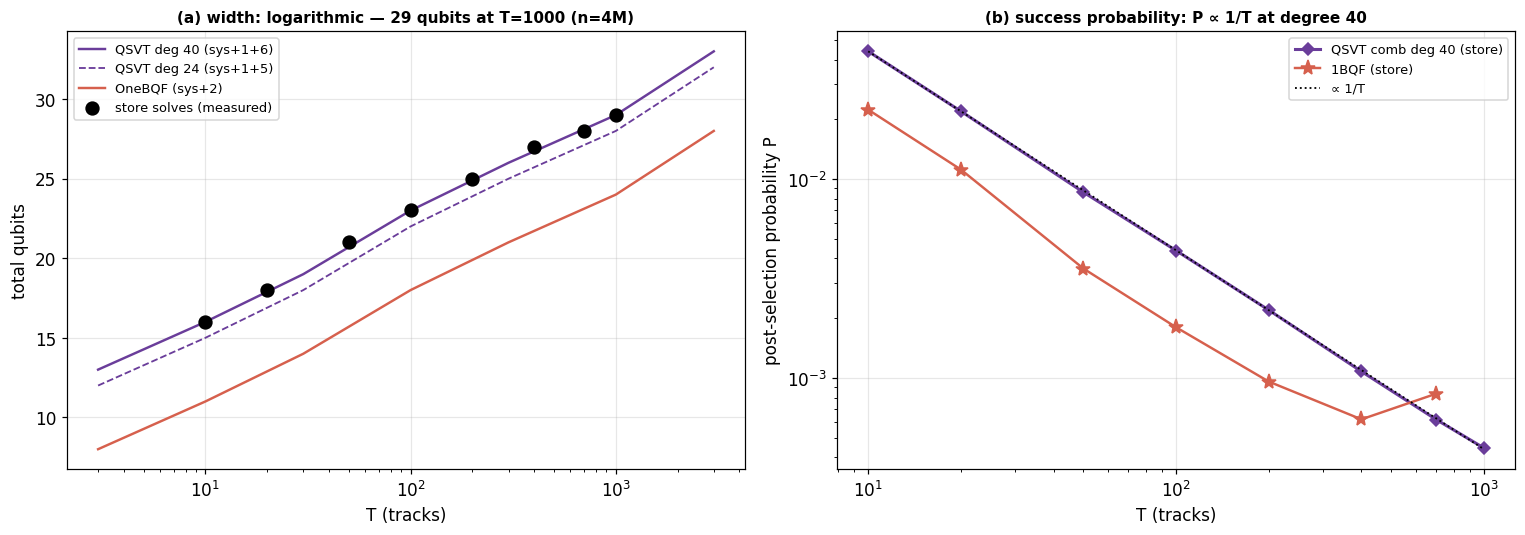

saved qsvt_width_and_P


In [2]:
# measured qubits + P from the qsvt solution metadata
idxQ=S.solves_index("qsvt",3.0,0.0)
rows=[]
for _,r in idxQ.iterrows():
    d=qp.load_solution(r["sol_key"])
    rows.append(dict(n_trk=int(r["n_trk"]),rep=int(r["rep"]),n_seg=int(d["n_seg"]),
                     n_qubits=int(d.get("n_qubits",0)),P=float(d.get("P_anc",np.nan)),
                     degree=int(d.get("degree",40))))
Q=pd.DataFrame(rows).drop_duplicates(subset=["n_trk","rep"])
qb=Q.groupby("n_trk").agg(n_seg=("n_seg","mean"),q=("n_qubits","max"),P=("P","mean"))
print(qb.round(5).to_string())
p1bqf=g3[g3.solver=="quantum"].groupby("n_trk")["P_anc"].mean()
fig,ax=plt.subplots(1,2,figsize=(14,5))
Ts=np.array([3,10,30,100,300,1000,3000])
ax[0].plot(Ts,np.ceil(np.log2(4*Ts**2))+7,'-',color="#6a3d9a",lw=1.6,label="QSVT deg 40 (sys+1+6)")
ax[0].plot(Ts,np.ceil(np.log2(4*Ts**2))+6,'--',color="#6a3d9a",lw=1.2,label="QSVT deg 24 (sys+1+5)")
ax[0].plot(Ts,np.ceil(np.log2(4*Ts**2))+2,'-',color="#d6604d",lw=1.6,label="OneBQF (sys+2)")
ax[0].scatter(qb.index,qb.q,s=70,color="k",zorder=5,label="store solves (measured)")
ax[0].set_xscale("log"); ax[0].set_xlabel("T (tracks)"); ax[0].set_ylabel("total qubits")
ax[0].set_title("(a) width: logarithmic — 29 qubits at T=1000 (n=4M)",fontweight="bold",fontsize=10)
ax[0].legend(fontsize=8.5)
ax[1].plot(qb.index,qb.P,'D-',color="#6a3d9a",lw=2,label="QSVT comb deg 40 (store)")
ax[1].plot(p1bqf.index,p1bqf.values,'*-',color="#d6604d",lw=1.6,ms=10,label="1BQF (store)")
tt=np.array(sorted(qb.index)); ax[1].plot(tt,qb.P.iloc[0]*qb.index[0]/tt,'k:',lw=1.2,label="∝ 1/T")
ax[1].set_xscale("log"); ax[1].set_yscale("log")
ax[1].set_xlabel("T (tracks)"); ax[1].set_ylabel("post-selection probability P")
ax[1].set_title("(b) success probability: P ∝ 1/T at degree 40",fontweight="bold",fontsize=10)
ax[1].legend(fontsize=8.5)
fig.tight_layout()
for ext,dpi in (("pdf",600),("png",300)): fig.savefig(OUT/f"qsvt_width_and_P.{ext}",dpi=dpi,bbox_inches="tight",facecolor="white")
plt.show(); print("saved qsvt_width_and_P")

## 2. The metrics vs depth — sweeping the polynomial degree

Degree = walk calls per shot = the per-shot depth knob. We sweep it at each T and
read the metrics at the working point (τ placed for eff ≥ 99 %, false accepted),
plus the success probability — because $P$ depends on the degree too: a
half-resolved comb (low $d$) passes more of the uniform $b$, so $P$ is *higher*,
while a fully resolved comb (high $d$) passes only the true-line weight,
$P\to\mathcal O(1/T)$.

In [3]:
DEGS=[8,12,16,20,24,28,32,40,56]
SWEEP_T=[(50,(0,1,2)),(100,(0,1,2)),(200,(0,1,2)),(400,(0,1,2)),(700,(0,)),(1000,(0,))]
idxC=S.solves_index("classical",3.0,0.0)
def classical_sol(event_key,ham_key):
    c=idxC[(idxC["event_key"]==event_key)&(idxC["ham_key"]==ham_key)]
    return np.asarray(qp.load_solution(c.iloc[0]["sol_key"])["sol"],float) if len(c) else None
def wp99(s,t):
    st=np.sort(s[t]); k=int(np.floor(0.01*len(st))); x=st[k]-1e-9
    act=s>x
    return float((act&t).sum()/t.sum()), float((act&~t).sum()/max(act.sum(),1))
CACHE=OUT/"degree_sweep.csv"
if CACHE.exists():
    SW=pd.read_csv(CACHE)
    print(f"loaded cached sweep ({len(SW)} rows); delete {CACHE} to recompute")
rows=[]
for T,reps in (SWEEP_T if not CACHE.exists() else []):
    idx=idxQ[idxQ.n_trk==T]
    for rep in reps:
        r=idx[idx.rep==rep]
        if not len(r): continue
        r=r.iloc[0]
        ev=qp.ensure_event(n_trk=T,rep=rep,sigma_scatt=1e-4,sigma_res=0.0,phi_max=0.2,hit_ineff=0.0)[0]
        ham=qp.build_hamiltonian(ev,epsilon=0.002,gamma=3.0,delta=1.0)
        truth=np.asarray(qp.truth_from_event(ev),bool)
        solC=classical_sol(r["event_key"],r["ham_key"])
        if solC is None: continue
        for dgr in DEGS:
            p=design_line_comb_inverse(degree=dgr,s=4.0)
            qv=QSVT(ham.A,np.asarray(ham.b,float).ravel(),poly=p,spectral_bounds=(0.5,7.5))
            sol,P=qv.solve_statevector()
            sQ=qp.rescale_to_signal(np.asarray(sol,float),solC,TAU)
            eff99,far99=wp99(sQ,truth)
            m=qp.metrics_at(sQ,truth,TAU)
            rows.append(dict(T=T,rep=rep,degree=dgr,P=P,far99=far99,
                             eff_fixed=m["segment_efficiency"],far_fixed=m["segment_false_rate"],
                             lcu=int(np.ceil(np.log2(dgr+1))),
                             total_depth=dgr*AA(P)))
        print(f"  T={T} rep={rep} done",flush=True)
if rows:
    SW=pd.DataFrame(rows)
    SW.to_csv(CACHE,index=False)
piv=SW.groupby(["T","degree"])[["far99","P","total_depth"]].mean()
print(piv.round(4).to_string())

loaded cached sweep (126 rows); delete /data/bfys/gscriven/Quantum_Track_Reconstruction/QSVT/Segment_level_studies/outputs/depth_and_qubits/degree_sweep.csv to recompute
              far99       P  total_depth
T    degree                             
50   8       0.0161  0.1004      19.8279
     12      0.0128  0.0713      35.2870
     16      0.0065  0.0686      47.9620
     20      0.0065  0.0111     149.0602
     24      0.0065  0.0388      95.6845
     28      0.0065  0.0187     160.6468
     32      0.0065  0.0115     233.9095
     40      0.0065  0.0086     338.5612
     56      0.0065  0.0090     463.4843
100  8       0.0522  0.0963      20.2443
     12      0.0000  0.0677      36.2118
     16      0.0000  0.0652      49.2296
     20      0.0000  0.0065     195.1655
     24      0.0000  0.0345     101.4244
     28      0.0000  0.0143     183.7663
     32      0.0000  0.0070     299.6348
     40      0.0000  0.0044     474.4841
     56      0.0000  0.0046     646.4746
200  8    

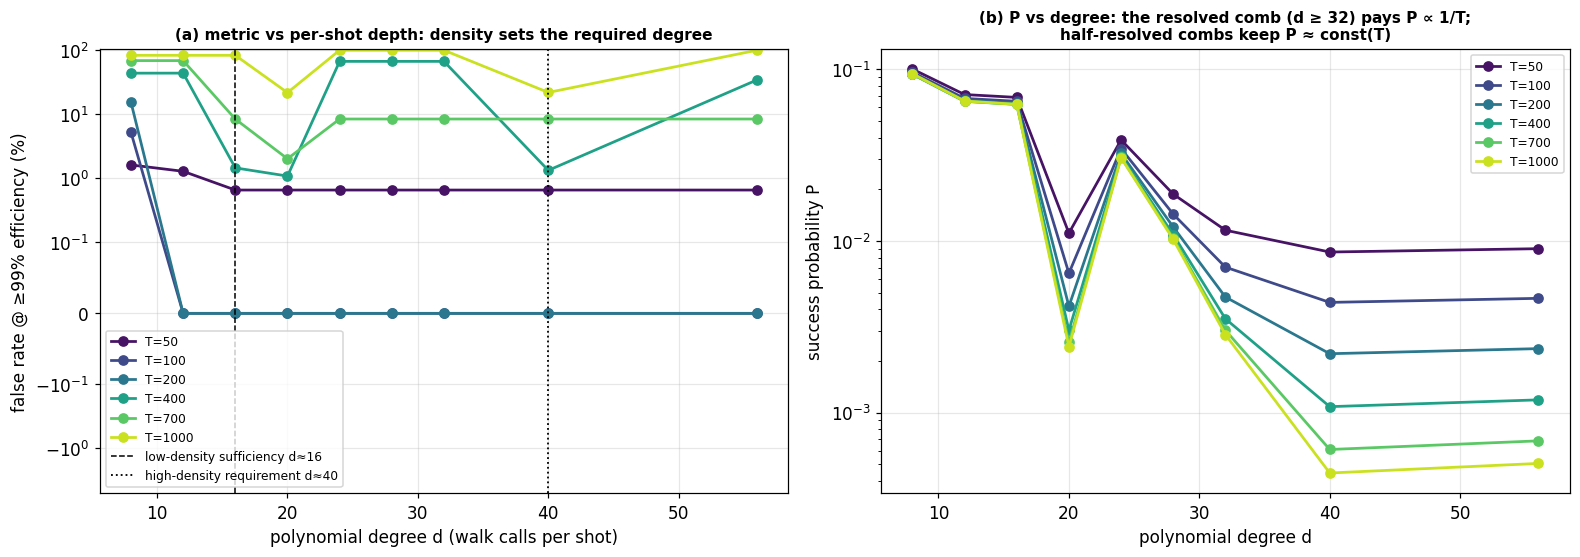

saved qsvt_metrics_vs_degree


In [4]:
fig,ax=plt.subplots(1,2,figsize=(14.5,5.2))
cm=plt.cm.viridis(np.linspace(0.05,0.92,len(SWEEP_T)))
for c,(T,_) in zip(cm,SWEEP_T):
    d=SW[SW["T"]==T].groupby("degree")["far99"].mean()
    ax[0].plot(d.index,100*d.values,'o-',color=c,lw=1.8,label=f"T={T}")
ax[0].axvline(16,color="k",ls="--",lw=1,label="low-density sufficiency d≈16")
ax[0].axvline(40,color="k",ls=":",lw=1.2,label="high-density requirement d≈40")
ax[0].set_xlabel("polynomial degree d (walk calls per shot)")
ax[0].set_ylabel("false rate @ ≥99% efficiency (%)")
ax[0].set_yscale("symlog",linthresh=0.1)
ax[0].set_title("(a) metric vs per-shot depth: density sets the required degree",fontweight="bold",fontsize=10)
ax[0].legend(fontsize=8)
for c,(T,_) in zip(cm,SWEEP_T):
    d=SW[SW["T"]==T].groupby("degree")["P"].mean()
    ax[1].plot(d.index,d.values,'o-',color=c,lw=1.8,label=f"T={T}")
ax[1].set_xlabel("polynomial degree d"); ax[1].set_ylabel("success probability P")
ax[1].set_yscale("log")
ax[1].set_title("(b) P vs degree: the resolved comb (d ≥ 32) pays P ∝ 1/T;\nhalf-resolved combs keep P ≈ const(T)",fontweight="bold",fontsize=10)
ax[1].legend(fontsize=8)
fig.tight_layout()
for ext,dpi in (("pdf",600),("png",300)): fig.savefig(OUT/f"qsvt_metrics_vs_degree.{ext}",dpi=dpi,bbox_inches="tight",facecolor="white")
plt.show(); print("saved qsvt_metrics_vs_degree")

## 3. The total-depth law — walk calls including amplitude amplification

Total walk calls per delivered solution $\approx d\times\pi/(4\sqrt{P(d,T)})$.
The two effects fight: raising $d$ sharpens the comb (better metrics, §2a) but
suppresses $P$ (more amplification, §2b). The sweep splits the regimes:

- **d ≈ 16 is remarkably cheap and good:** it matches the resolved d = 40 comb's
  working-point metrics all the way to **T = 700** (far@99 %: 0.65/0/0/1.45/8.4 %)
  while its line tails keep $P\approx5\%$ independent of T → **≈ 50 total walk
  calls, flat in T**.
- **The degree–metric landscape is non-monotonic:** intermediate degrees
  (d ≈ 20–32) hit unlucky Chebyshev-fit configurations whose elevated false bulk
  swallows the contaminated-true tail — the 99 % working point then cliffs
  (66–100 % false at T ≥ 400). Degrees must be *validated*, not assumed monotone.
- **T = 1000 needs the resolved d = 40 comb** (22 % vs 83 % at d = 16), paying
  $P\propto1/T$ → total depth $\propto\sqrt T$ (≈ 1 500 calls).
- **The contamination floor is degree-independent** (1.3 % @ 400 → 8.4 % @ 700 →
  22 % @ 1000): at extreme density the 99 %-efficiency *target*, not the
  circuit, is the expensive part — relaxing to ~97–98 % efficiency returns
  far ≈ 0 at fixed depth (nb01 §1).

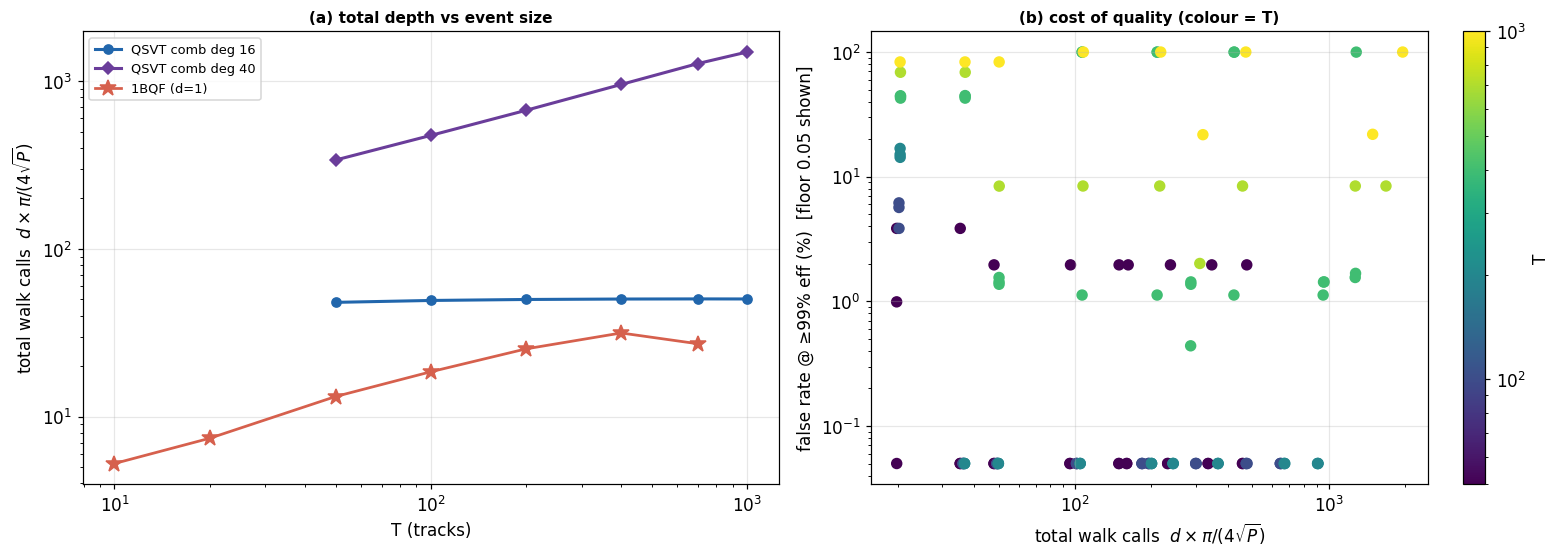

saved qsvt_total_depth
   T  qubits  far99_d16_pct  total_calls_d16  far99_d40_pct   P_d40  total_calls_d40
  50      21           0.65               48           0.65 0.00862              339
 100      23           0.00               49           0.00 0.00438              474
 200      25           0.00               50           0.00 0.00220              670
 400      27           1.45               50           1.33 0.00108              955
 700      28           8.40               50           8.41 0.00061             1273
1000      29          83.20               50          21.86 0.00044             1491


In [5]:
fig,ax=plt.subplots(1,2,figsize=(14.5,5.2))
for dgr,c,mk in [(16,"#2166ac","o"),(40,"#6a3d9a","D")]:
    d=SW[SW.degree==dgr].groupby("T")[["P"]].mean()
    ax[0].plot(d.index,[dgr*AA(p) for p in d.P],mk+"-",color=c,lw=2,label=f"QSVT comb deg {dgr}")
p1=g3[g3.solver=="quantum"].groupby("n_trk")["P_anc"].mean()
ax[0].plot(p1.index,[1*AA(p) for p in p1.values],'*-',color="#d6604d",lw=1.8,ms=11,label="1BQF (d=1)")
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("T (tracks)"); ax[0].set_ylabel(r"total walk calls  $d\times\pi/(4\sqrt{P})$")
ax[0].set_title("(a) total depth vs event size",fontweight="bold",fontsize=10)
ax[0].legend(fontsize=8.5)
# (b) quality vs total depth (all sweep points)
sc=ax[1].scatter(SW.total_depth,100*np.maximum(SW.far99,5e-4),c=SW["T"],cmap="viridis",
                 s=42,norm=plt.matplotlib.colors.LogNorm())
ax[1].set_xscale("log"); ax[1].set_yscale("log")
ax[1].set_xlabel(r"total walk calls  $d\times\pi/(4\sqrt{P})$")
ax[1].set_ylabel("false rate @ ≥99% eff (%)  [floor 0.05 shown]")
ax[1].set_title("(b) cost of quality (colour = T)",fontweight="bold",fontsize=10)
plt.colorbar(sc,ax=ax[1],label="T")
fig.tight_layout()
for ext,dpi in (("pdf",600),("png",300)): fig.savefig(OUT/f"qsvt_total_depth.{ext}",dpi=dpi,bbox_inches="tight",facecolor="white")
plt.show(); print("saved qsvt_total_depth")

# headline table
tab=[]
for T,_ in SWEEP_T:
    d16=SW[(SW["T"]==T)&(SW.degree==16)].mean(numeric_only=True)
    d40=SW[(SW["T"]==T)&(SW.degree==40)].mean(numeric_only=True)
    q=int(np.ceil(np.log2(4*T**2)))
    tab.append(dict(T=T,qubits=q+7,far99_d16_pct=round(100*d16.far99,2),
                    total_calls_d16=int(round(d16.total_depth)),
                    far99_d40_pct=round(100*d40.far99,2),
                    P_d40=round(d40.P,5),total_calls_d40=int(round(d40.total_depth))))
print(pd.DataFrame(tab).to_string(index=False))

## 4. What one walk call costs in gates

The numbers above count **walk-operator calls** — the right unit, since the 1BQF
is one call of the same operator. The gate cost per call depends on how $A$ is
block-encoded:

- **This build (dense dilation):** the call is a $2^{n_s+1}$-dim unitary applied
  exactly in simulation; synthesising it into gates scales as $O(4^{n_s})$ —
  fine for validation, not for deployment (anchor below).
- **Sparse-oracle block-encoding (the deployment path):** $A/s$ has ≤ 3 nonzeros
  per row with values from a fixed small set, so the standard sparse-access
  construction gives a walk call of $O(\text{polylog}\,n)$ gates — i.e. per-call
  depth grows like the *qubit count*, logarithmically in event size. That is the
  next build step (with the parity/phase-angle path).

In [6]:
# dense-dilation gate anchor at tiny size (worst case, for scale)
from qiskit import transpile
ev=qp.ensure_event(n_trk=3,rep=0,sigma_scatt=1e-4,sigma_res=0.0,phi_max=0.2,hit_ineff=0.0)[0]
ham=qp.build_hamiltonian(ev,epsilon=0.002,gamma=3.0,delta=1.0)
p24=design_line_comb_inverse(degree=24,s=4.0)
qv=QSVT(ham.A,np.asarray(ham.b,float).ravel(),poly=p24,spectral_bounds=(0.5,7.5))
qc=qv.build_circuit()
t0=time.time(); tq=transpile(qc,basis_gates=["rz","sx","x","cx"],optimization_level=1); dt=time.time()-t0
ops=tq.count_ops()
print(f"T=3 event (n={ham.n_segments}, {qv.total_qubits} qubits, deg 24): "
      f"transpiled depth={tq.depth()}, cx={ops.get('cx',0)}, total gates={sum(ops.values())}  ({dt:.0f}s)")
print("dense-dilation synthesis scales O(4^n_sys) — the sparse-oracle path replaces this with O(polylog n) per call.")

T=3 event (n=36, 12 qubits, deg 24): transpiled depth=330261, cx=84175, total gates=554062  (7s)
dense-dilation synthesis scales O(4^n_sys) — the sparse-oracle path replaces this with O(polylog n) per call.


## 5. Read-off

- **Width is logarithmic and measured:** 16 qubits at T=10 → **29 qubits at
  T=1000 (4 M segments, store solve)** — LHCb-multiplicity events fit in ~30
  qubits of width at any degree considered.
- **The required degree is set by the density, and is non-monotonic in between.**
  A half-resolved d ≈ 16 comb matches the resolved d = 40 metrics up to
  **T = 700**, keeps $P\approx5\%$ independent of T, and runs at a **flat ≈ 50
  total walk calls**; intermediate degrees (20–32) can cliff at the 99 % working
  point at T ≥ 400 and must be validated. Only T = 1000 requires d = 40, which
  pays $P\propto1/T$ → total depth $\propto\sqrt T$ (≈ 1 500 calls).
- **At extreme density the metric target is the real cost driver:** the
  contamination floor (true tracks fused into tangles, nb01 §3) raises the
  false price of holding 99 % efficiency from 1.3 % (T=400) to 22 % (T=1000)
  even at d = 40 — while relaxing to ~97–98 % efficiency returns far ≈ 0 at
  fixed depth. Depth buys comb resolution; no depth buys back contamination.
- **The 1BQF** sits at 5–30 total calls (d = 1, same $1/\sqrt P$ growth) — about
  30× shallower than the high-density QSVT — but its metric frontier is not
  competitive (44 % false at 99 % efficiency already at T = 400).
- **Per-call gate cost** is the open engineering axis: $O(\text{polylog}\,n)$
  with a sparse-oracle block-encoding (next build step; the dense-dilation
  anchor above is the simulation-only worst case), so the end-to-end picture is
  (calls from the table) × (polylog-n gates per call).